# Correlation Functions

In this notebook we construct the 1-time lag autocorrelation and cross-correlation functions for the time-domain quadratures.

In [1]:
# IMPORTS
# =======
import os
import sys

import matplotlib.pyplot as plt
#%matplotlib widget
import numpy as np
from tqdm import tqdm
from IPython.display import display, clear_output
import time

import importlib
import LKIPA_library as lib
importlib.reload(lib)

<module 'LKIPA_library' from '/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Time-Frequency Analysis/LKIPA_library.py'>

## 1. Import quadrature data from hdf5 file

In [2]:
folder = r'/media/nanophys-meas/DR_BACKUP/Jai LKIPA Data/2026-07/Time series'  # Choose folder for current month and measurement type

file = sorted(                                                                 # Get the most recent hdf5 file in the folder 
        (f for f in os.listdir(folder) if f.endswith('.hdf5')),
        key=lambda f: os.path.getmtime(os.path.join(folder, f))
    )[-1]   

myrun = file.split('.')[0]                                                      # Get the run name from the file name

file = os.path.join(folder, file)

pump_idx = 0                                                                   # set pump index for desired pump amplitude

pump_freq, pump_amp, df_data, f_NCO, dc_bias, N_pixels, I_arr, Q_arr, t_arr, fs_data = lib.retrieve_data(folder, file, myrun, pump_idx)

## 2. Construct correlation functions


In [3]:
auto_xx, auto_pp, cross_xp = lib.get_correlation(I_arr, Q_arr)

auto_xx = lib.origin_removed(auto_xx)
auto_pp = lib.origin_removed(auto_pp)
cross_xp = lib.origin_removed(cross_xp)

t_muS = lib.origin_removed(t_arr) * 1e-3

100%|█████████████████████████████████████████| 100/100 [00:05<00:00, 19.83it/s]


## 3. Plotting

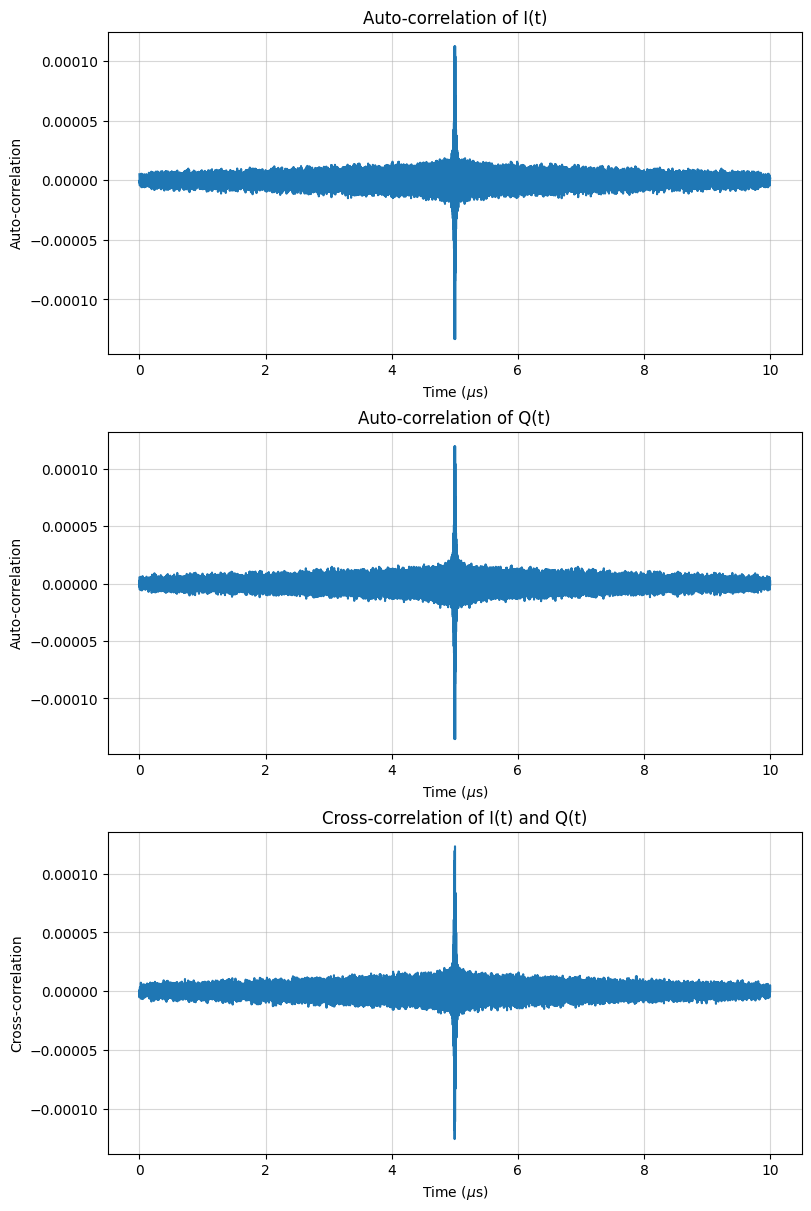

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(8, 12), constrained_layout=True)

axs[0].plot(t_muS, auto_xx)
axs[0].set_title('Auto-correlation of I(t)')
axs[0].set_xlabel('Time ($\\mu$s)')
axs[0].set_ylabel('Auto-correlation')
axs[0].grid(alpha=0.5)   

axs[1].plot(t_muS, auto_pp)
axs[1].set_title('Auto-correlation of Q(t)')
axs[1].set_xlabel('Time ($\\mu$s)')
axs[1].set_ylabel('Auto-correlation')
axs[1].grid(alpha=0.5)   

axs[2].plot(t_muS, cross_xp)
axs[2].set_title('Cross-correlation of I(t) and Q(t)')
axs[2].set_xlabel('Time ($\\mu$s)')
axs[2].set_ylabel('Cross-correlation')
axs[2].grid(alpha=0.5)
